In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv('../data/raw/ai4i2020.csv')
print("Data loaded!", df.shape)

Data loaded! (10000, 14)


In [26]:
import subprocess
subprocess.run(['pip', 'install', 'shap', 'lightgbm'], capture_output=True)
print("Installing... done!")

Installing... done!


In [27]:
import shap
import lightgbm as lgb
print("SHAP version:", shap.__version__)
print("LightGBM version:", lgb.__version__)

SHAP version: 0.49.1
LightGBM version: 4.6.0


In [28]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

X = df[['Air temperature [K]', 'Process temperature [K]',
        'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]
y = df['Machine failure']

# Rename columns — special characters hatao
X.columns = ['Air_temp', 'Process_temp', 'Rotational_speed', 'Torque', 'Tool_wear']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = LGBMClassifier(n_estimators=100, random_state=42,
                        verbose=-1, n_jobs=1)
model.fit(X_train, y_train)

print("Model trained!")
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Model trained!
Train size: (8000, 5), Test size: (2000, 5)


In [29]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated!")
print("Shape:", shap_values.shape)

SHAP values calculated!
Shape: (2000, 5)


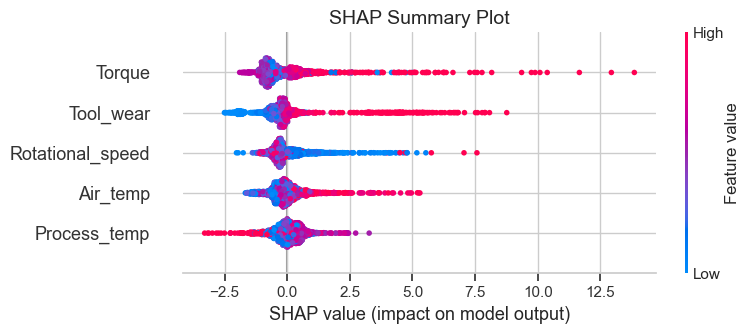

Saved!


In [30]:
# SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/13_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

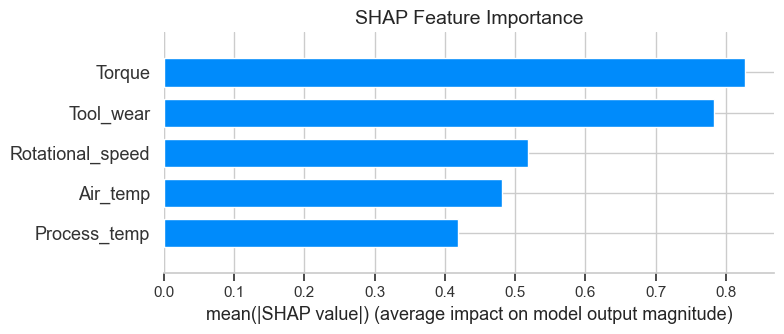

Saved!


In [31]:
# SHAP Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/14_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

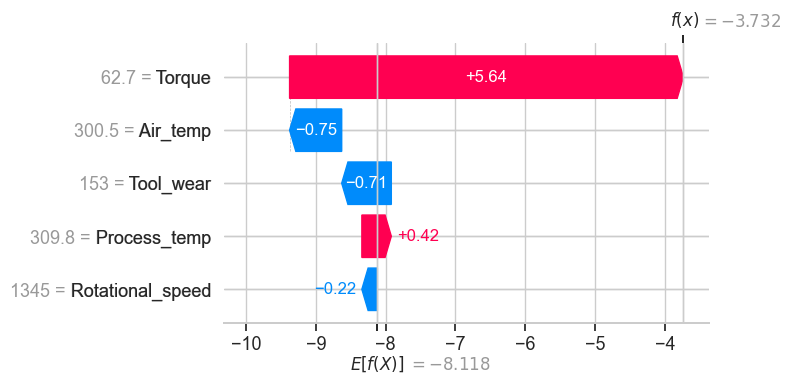

Saved!


In [32]:
# SHAP Waterfall Plot - single prediction explain karo
explainer2 = shap.TreeExplainer(model)
shap_explanation = explainer2(X_test)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation[0], show=False)
plt.tight_layout()
plt.savefig('../reports/figures/15_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

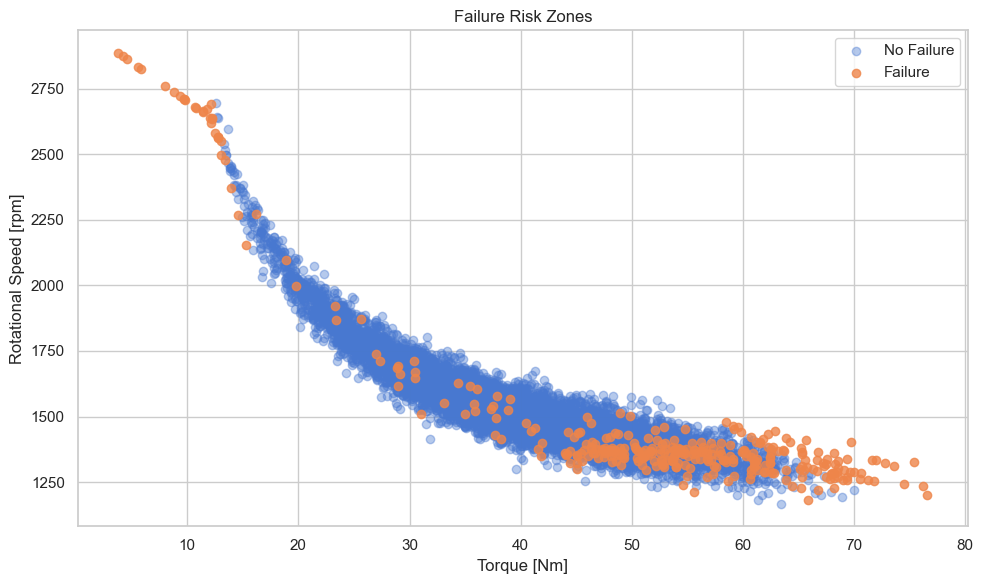

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

no_failure = df[df['Machine failure'] == 0]
failure = df[df['Machine failure'] == 1]

plt.scatter(
    no_failure['Torque [Nm]'],
    no_failure['Rotational speed [rpm]'],
    alpha=0.4,
    label='No Failure'
)

plt.scatter(
    failure['Torque [Nm]'],
    failure['Rotational speed [rpm]'],
    alpha=0.8,
    label='Failure'
)

plt.xlabel('Torque [Nm]')
plt.ylabel('Rotational Speed [rpm]')
plt.title('Failure Risk Zones')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    '../reports/figures/18_failure_risk_zones.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

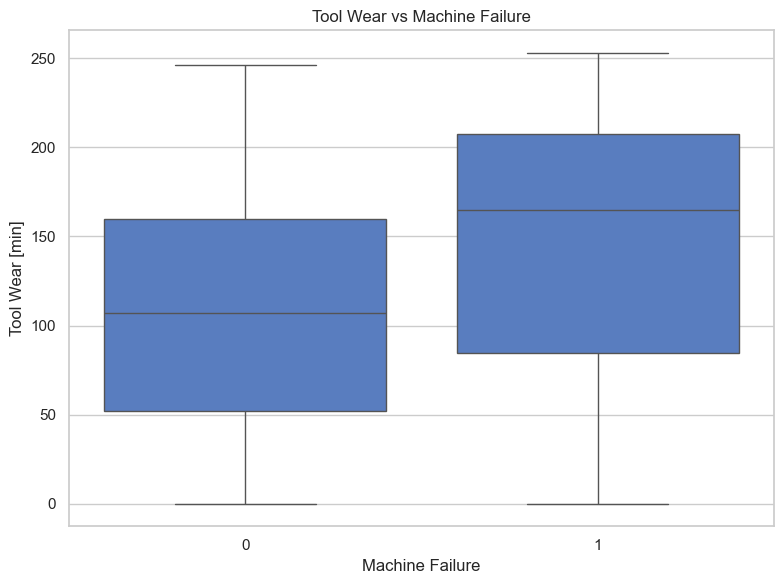

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Machine failure',
    y='Tool wear [min]'
)

plt.title('Tool Wear vs Machine Failure')
plt.xlabel('Machine Failure')
plt.ylabel('Tool Wear [min]')

plt.tight_layout()

plt.savefig(
    '../reports/figures/18_tool_wear_failure.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()